In [57]:
# AUTOGENERATED! DO NOT EDIT! File to edit: ../../nbs/dvc.experiment.ipynb.

# %% auto 0
__all__ = ["parse_params", "parse_metrics", "parse_experiment", "parse_experiments", "load_experiments"]

# %% ../../nbs/dvc.experiment.ipynb 3
import json
from typing import Generator


# %% ../../nbs/dvc.experiment.ipynb 4
def parse_params(record):
    params_node = record.get("data", {}).get("params", {})
    params = {}
    for k, v in params_node.items():
        params.update(v.get("data", {}))
    return params


def parse_metrics(record):
    metrics_node = record.get("data", {}).get("metrics", {})
    metrics = {}
    for k, v in metrics_node.items():
        metrics.update(v.get("data", {}))
    return metrics


def parse_experiment(record):
    return {
        "id": record["rev"],
        "name": record["name"],
        "params": parse_params(record),
        "metrics": parse_metrics(record),
    }


def parse_experiments(data: list[dict]) -> Generator[dict, None, None]:
    for node in data:
        if node.get("error"):
            continue
        commit = node.get("rev")
        if experiments := (node.get("experiments") or []):
            for experiment in experiments:
                for rev in experiment.get("revs") or []:
                    if not rev.get("error"):
                        yield {"commit": commit, **parse_experiment(rev)}
        else:
            yield {"commit": commit, **parse_experiment(node)}


def load_experiments(json_filepath):
    with open(json_filepath, "r") as f:
        data = json.load(f)
    return list(parse_experiments(data))


In [58]:
import itertools
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn

In [59]:
def sorted_tuple(x):
    return tuple(sorted(x))

In [60]:
def jprint(obj):
    print(json.dumps(obj, indent=2))

In [61]:
filepaths = list(Path("../tmp/experiments/").glob("*.json"))
experiments = [exp for fp in filepaths for exp in load_experiments(fp)]
print(f"{len(experiments)} experiments")
jprint(next(iter(experiments), None))

35 experiments
{
  "commit": "workspace",
  "id": "workspace",
  "name": null,
  "params": {
    "dataset": {
      "path": "bdsaglam/musique-mini",
      "name": "answerable",
      "split": "validation"
    },
    "model": {
      "name": "Qwen/Qwen2.5-1.5B-Instruct",
      "temperature": 0.3,
      "top_p": 0.95
    },
    "retriever": {
      "name": "semantic",
      "top_k": 2
    },
    "run": 1
  },
  "metrics": {
    "exact_match": 0.0033333333333333335,
    "f1": 0.014063492063492061
  }
}


In [62]:
df = pd.json_normalize(experiments)
print(f"{len(df)} experiments before preprocessing")
df.head()

35 experiments before preprocessing


,commit,id,name,params.dataset.path,params.dataset.name,params.dataset.split,params.model.name,params.model.temperature,params.model.top_p,params.retriever.name,params.retriever.top_k,params.run,metrics.exact_match,metrics.f1
0,workspace,workspace,None,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-1.5B-Instruct,0.3,0.95,semantic,2,1,0.003333,0.014063
1,23fccfb44a69b44ff2a0394c46dc666bccb8217f,84856f4692201f325ee0f578d9fd6dcf6e3eed55,doped-amah,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-1.5B-Instruct,0.3,0.95,hybrid,2,1,0.003333,0.014063
2,23fccfb44a69b44ff2a0394c46dc666bccb8217f,12386bad001d070217393fd8b17bc8d17d3448ac,fixed-junk,bdsaglam/musique-mini,answerable,validation,meta-llama/Llama-3.1-8B-Instruct,0.3,0.95,lexical,2,1,0.183333,0.216123
3,23fccfb44a69b44ff2a0394c46dc666bccb8217f,fa51a709fed956f12e5972a443e53c0056b46b72,potty-good,bdsaglam/musique-mini,answerable,validation,bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique,0.3,0.95,lexical,2,1,0.110000,0.175368
4,23fccfb44a69b44ff2a0394c46dc666bccb8217f,6ae480b472be4191bb44ecfc8b0ce0131701169d,eight-vela,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-7B-Instruct,0.3,0.95,hybrid,1,1,0.176667,0.264865


In [63]:
param_cols = [col for col in df.columns if col.startswith("params.")]
metric_cols = [col for col in df.columns if col.startswith("metrics.")]

In [64]:
df['params.model.temperature'] = df['params.model.temperature'].astype(float).map(lambda x: round(x, 2))
df['params.model.top_p'] = df['params.model.top_p'].astype(float).map(lambda x: round(x, 2))

In [65]:
df.dropna(subset=param_cols + metric_cols, inplace=True, how="any")
df.drop_duplicates(subset=param_cols, inplace=True, keep='last')

print(f"{len(df)} experiments after preprocessing")
df.head()

23 experiments after preprocessing


,commit,id,name,params.dataset.path,params.dataset.name,params.dataset.split,params.model.name,params.model.temperature,params.model.top_p,params.retriever.name,params.retriever.top_k,params.run,metrics.exact_match,metrics.f1
1,23fccfb44a69b44ff2a0394c46dc666bccb8217f,84856f4692201f325ee0f578d9fd6dcf6e3eed55,doped-amah,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-1.5B-Instruct,0.3,0.95,hybrid,2,1,0.003333,0.014063
2,23fccfb44a69b44ff2a0394c46dc666bccb8217f,12386bad001d070217393fd8b17bc8d17d3448ac,fixed-junk,bdsaglam/musique-mini,answerable,validation,meta-llama/Llama-3.1-8B-Instruct,0.3,0.95,lexical,2,1,0.183333,0.216123
3,23fccfb44a69b44ff2a0394c46dc666bccb8217f,fa51a709fed956f12e5972a443e53c0056b46b72,potty-good,bdsaglam/musique-mini,answerable,validation,bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique,0.3,0.95,lexical,2,1,0.110000,0.175368
5,23fccfb44a69b44ff2a0394c46dc666bccb8217f,2f7e5409654921fc611706984082b51f476f6c90,moire-tors,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-7B-Instruct,0.3,0.95,lexical,1,1,0.126667,0.202414
6,23fccfb44a69b44ff2a0394c46dc666bccb8217f,477ddade8c68f556b0d1b790ebe53b33800440a9,solid-tics,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-1.5B-Instruct,0.3,0.95,hybrid,3,1,0.003333,0.006333


In [66]:
for col in param_cols:
    values = list(df[col].unique())
    print(f"- {col}: {values}")
    print()

- params.dataset.path: ['bdsaglam/musique-mini']

- params.dataset.name: ['answerable']

- params.dataset.split: ['validation']

- params.model.name: ['Qwen/Qwen2.5-1.5B-Instruct', 'meta-llama/Llama-3.1-8B-Instruct', 'bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique', 'Qwen/Qwen2.5-7B-Instruct']

- params.model.temperature: [0.3, 0.0]

- params.model.top_p: [0.95]

- params.retriever.name: ['hybrid', 'lexical', 'semantic']

- params.retriever.top_k: [2, 1, 3]

- params.run: [1]



In [67]:
df.to_json('exps.jsonl', orient='records', lines=True)

## Setup remaining experiments

In [68]:
df = pd.read_json('exps.jsonl', orient='records', lines=True)

In [69]:
def produce_experiment_configs(common_params, varying_params):
    # Generate all possible combinations of parameters
    varying_params = {**common_params, **varying_params}
    keys = varying_params.keys()
    values = varying_params.values()
    for instance in itertools.product(*values):
        yield dict(zip(keys, instance))

In [70]:
def produce_all_experiment_configs(common_params: dict, varying_params_list: list[dict]):
    for params in varying_params_list:
        for exp_config in produce_experiment_configs(common_params, params):
            yield exp_config

In [71]:
common_params = {
    "params.dataset.path": ["bdsaglam/musique-mini"],
    "params.dataset.name": ["answerable"],
    "params.dataset.split": ['validation'],
    "params.model.name": [
        # "Qwen/Qwen2.5-1.5B-Instruct",
        # "Qwen/Qwen2.5-7B-Instruct",
        # "meta-llama/Llama-3.1-8B-Instruct",
        # "bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique",
        "bdsaglam/Llama-3.1-8B-Instruct-ragent-grpo-musique-scaled",
    ],
    "params.model.temperature": [
        # 0.0,
        0.3,
        0.5,
        # 0.7,
    ],
    "params.model.top_p": [
        0.95,
    ],
    "params.retriever.name": [
        # "semantic",
        "lexical",
        "hybrid",
    ],
    "params.retriever.top_k": [
        1,
        2,
        3,
    ],
    "params.run": [
        1,
        # 2,
        # 3,
    ],
}

In [72]:
varying_params_list = [
    {
        "params.run": [
            1,
            # 2,
            # 3,
        ],
    }
]

In [73]:
exp_configs = list(produce_all_experiment_configs(common_params, varying_params_list))
target_params = list(exp_configs[0].keys())
print(f"{len(exp_configs)} experiment configurations")
print(target_params)

12 experiment configurations
['params.dataset.path', 'params.dataset.name', 'params.dataset.split', 'params.model.name', 'params.model.temperature', 'params.model.top_p', 'params.retriever.name', 'params.retriever.top_k', 'params.run']


In [74]:
def preprocess_config(config):
    return {k: round(v, 2) if isinstance(v, float) else v for k, v in config.items()}

In [75]:
if len(df):
    existing_configs = [preprocess_config(config) for config in df[target_params].to_dict(orient="records")]
    existing_configs[0]
else:
    existing_configs = []

print("Existing exps:", len(existing_configs))

Existing exps: 23


In [76]:
# find the missing configurations
missing_configs = [
    preprocess_config(dict(kv))
    for kv in list(
        {tuple(sorted(config.items())) for config in exp_configs}
        - {tuple(sorted(config.items())) for config in existing_configs}
    )
]
print(f"{len(missing_configs)} missing configurations")

12 missing configurations


In [77]:
def make_command(exp_config):
    lines = ["dvc exp run --queue"]
    for target_param in target_params:
        arg_name = target_param.split(".", 1)[-1]
        arg_value = exp_config[target_param]
        lines.append(f"-S {arg_name}='{arg_value}'")

    command = " \\\n    ".join(lines)
    return command

In [78]:
with open("run.sh", "w") as f:
    f.write("#!/bin/sh\n\n")
    for exp_config in missing_configs:
        f.write(make_command(exp_config))
        f.write("\n\n")

In [79]:
missing_configs[0]

{'params.dataset.name': 'answerable',
 'params.dataset.path': 'bdsaglam/musique-mini',
 'params.dataset.split': 'validation',
 'params.model.name': 'bdsaglam/Llama-3.1-8B-Instruct-ragent-grpo-musique-scaled',
 'params.model.temperature': 0.3,
 'params.model.top_p': 0.95,
 'params.retriever.name': 'hybrid',
 'params.retriever.top_k': 3,
 'params.run': 1}

In [80]:
existing_configs[0]

{'params.dataset.path': 'bdsaglam/musique-mini',
 'params.dataset.name': 'answerable',
 'params.dataset.split': 'validation',
 'params.model.name': 'Qwen/Qwen2.5-1.5B-Instruct',
 'params.model.temperature': 0.3,
 'params.model.top_p': 0.95,
 'params.retriever.name': 'hybrid',
 'params.retriever.top_k': 2,
 'params.run': 1}

## Inspect

In [81]:
target_params = [*param_cols]
target_params.remove('params.run')

In [82]:
df[['params.model.name', 'params.retriever.name', 'params.retriever.top_k', 'metrics.exact_match', 'metrics.f1']].sort_values(by='metrics.f1', ascending=False)

,params.model.name,params.retriever.name,params.retriever.top_k,metrics.exact_match,metrics.f1
15,Qwen/Qwen2.5-7B-Instruct,hybrid,1,0.176667,0.264865
18,meta-llama/Llama-3.1-8B-Instruct,hybrid,1,0.210000,0.262947
12,Qwen/Qwen2.5-7B-Instruct,hybrid,2,0.190000,0.262008
19,meta-llama/Llama-3.1-8B-Instruct,hybrid,2,0.213333,0.250381
21,Qwen/Qwen2.5-7B-Instruct,hybrid,3,0.163333,0.228675
1,meta-llama/Llama-3.1-8B-Instruct,lexical,2,0.183333,0.216123
3,Qwen/Qwen2.5-7B-Instruct,lexical,1,0.126667,0.202414
22,Qwen/Qwen2.5-7B-Instruct,lexical,3,0.120000,0.200818
14,bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique,hybrid,2,0.130000,0.184990
20,bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique,hybrid,3,0.133333,0.184614


In [83]:
# extract the model size from the model name, e.g. Qwen/Qwen2.5-1.5B-Instruct -> 1.5B
df['params.model.size'] = df['params.model.name'].str.extract(r'-([0-9.]+)B-').map(float)
df['params.model.size']

0     1.5
1     8.0
2     1.5
3     7.0
4     1.5
5     8.0
6     1.5
7     1.5
8     1.5
9     1.5
10    1.5
11    8.0
12    7.0
13    1.5
14    1.5
15    7.0
16    1.5
17    1.5
18    8.0
19    8.0
20    1.5
21    7.0
22    7.0
Name: params.model.size, dtype: float64

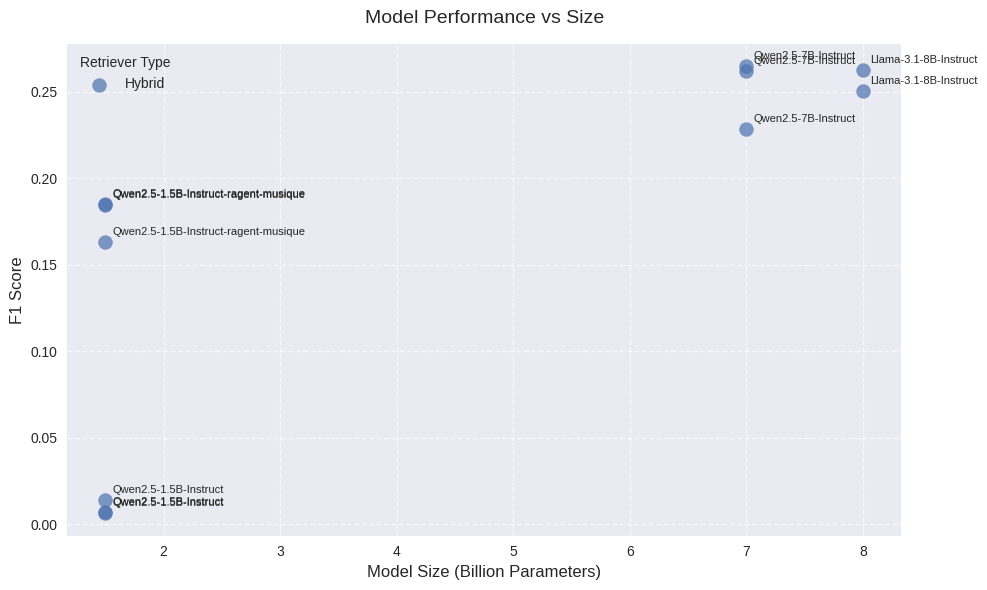

In [84]:
def plot_model_size_vs_f1(df):
    # Create publication-quality plot comparing model size vs F1 score
    plt.style.use('seaborn-v0_8')  # Use the updated seaborn style name
    plt.figure(figsize=(10, 6))

    # Customize appearance
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel('Model Size (Billion Parameters)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.title('Model Performance vs Size', fontsize=14, pad=15)

    # Add retriever type as color
    colors = {'hybrid': 'C0'}
    for retriever in colors:
        mask = df['params.retriever.name'] == retriever
        
        # Plot points
        plt.scatter(df[mask]['params.model.size'], 
                df[mask]['metrics.f1'],
                label=retriever.capitalize(),
                alpha=0.7,
                s=100,
                c=colors[retriever])
        
        # Add model names as annotations
        for idx in df[mask].index:
            model_name = df.loc[idx, 'params.model.name'].split('/')[-1]
            plt.annotate(model_name,
                        (df.loc[idx, 'params.model.size'], 
                        df.loc[idx, 'metrics.f1']),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=8)

    plt.legend(title='Retriever Type', title_fontsize=10)

    # Adjust layout and style
    plt.tight_layout()
    plt.show()


plot_model_size_vs_f1(df.loc[df['params.retriever.name'] == 'hybrid'])